### CD4 T-cell Milo Differential Abundance Analysis: Sex Effect
*Dataset: PICA Batch001–Batch007 (PICA0001–PICA0128)* \
*Analysis: Lineage-specific sex-associated neighbourhood differential abundance*

#### Aim
This notebook tests whether CD4 T-cell neighbourhood abundance differs between male and female donors using Milo.

*Note: This analysis was performed as a lineage-specific exploration of sex-associated compositional differences within CD4 T cells. The primary differential abundance results reported in the thesis were derived from the full-cohort compositional analysis, while Milo was used to provide higher-resolution neighbourhood-level insights.*

In [ ]:
import os
import mudata as mu
import pertpy as pt
import scanpy as sc
import pandas as pd
import mudata as mu
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

milo = pt.tl.Milo()

from pertpy.tools import Milo

: 

In [ ]:
mdata_cd4_sex = mu.read("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_milo_nhoods_built.h5mu")

In [ ]:
mdata_cd4_sex

NameError: name 'mdata_cd4_sex' is not defined

## Run Milo Differential Abundance Testing

In [ ]:
# Test for sex-associated changes in CD4 neighbourhood abundance
# Batch and age are included as covariates
milo.da_nhoods(
    mdata_cd4_sex,
    design="~ Batch + Age_years + Sex",
    model_contrasts="SexMale - SexFemale",    
    solver="pydeseq2"                 
)

Fitting size factors...
/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pydeseq2/dds.py:539: UserWarning: Every gene contains at least one zero, cannot compute log geometric means. Switching to iterative mode.
  self.fit_size_factors(


Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 6.26 seconds.

Fitting MAP dispersions...
... done in 6.53 seconds.

Fitting dispersions...
... done in 6.48 seconds.

Fitting MAP dispersions...
... done in 6.35 seconds.

Fitting dispersions...
... done in 6.43 seconds.

Fitting MAP dispersions...
... done in 6.44 seconds.

Fitting dispersions...
... done in 6.66 seconds.

Fitting MAP dispersions...
... done in 6.52 seconds.

Fitting dispersions...
... done in 6.41 seconds.

Fitting MAP dispersions...
... done in 6.59 seconds.

Fitting dispersions...
... done in 6.38 seconds.

Fitting MAP dispersions...
... done in 6.35 seconds.

Fitting dispersions...
... done in 6.59 seconds.

Fitting MAP dispersions...
... done in 6.45 seconds.

Fitting dispersions...
... done in 6.38 seconds.

Fitting MAP dispersions...
... done in 6.59 seconds.

Fitting dispersions...
... done in 6.47 seconds.

Fitting MAP dispersions...
... done in 6.35 seconds.

Fitting dispersions...
... done in 6.72 seconds.

Fitting MAP di

Log2 fold change & Wald test p-value: Sex Male vs Female
       baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
0      4.096742       -0.020233  0.257645 -0.078529  0.937407  0.988793
1      4.456991        0.406422  0.326003  1.246682  0.212514  0.727482
2      3.854566        0.137296  0.390319  0.351752  0.725024  0.938810
3      3.749896       -0.165740  0.270506 -0.612706  0.540071  0.886351
4      3.899418        0.521025  0.266308  1.956475  0.050409  0.564617
...         ...             ...       ...       ...       ...       ...
32144  2.157312       -0.303081  0.328007 -0.924009  0.355482  0.806440
32145  4.801573       -0.020600  0.427248 -0.048216  0.961544  0.992418
32146  4.902330        0.224680  0.336502  0.667693  0.504330  0.871852
32147  2.667069       -0.016386  0.356411 -0.045976  0.963329  0.992747
32148  3.522144        0.156687  0.361819  0.433052  0.664977  0.921237

[32149 rows x 6 columns]


... done in 2.78 seconds.



In [5]:
mdata_cd4_sex["milo"].var.columns.tolist()

['index_cell',
 'kth_distance',
 'logCPM',
 'logFC',
 'PValue',
 'FDR',
 'SpatialFDR']

In [6]:
mdata_cd4_sex["milo"].uns

{'sample_col': 'pica_id'}

In [ ]:
# Check model output values for basic quality control
print("Model uns:", mdata_cd4_sex["milo"].uns)

print("\nlogFC head:")
print(mdata_cd4_sex["milo"].var["logFC"].head(10))

print("\nlogFC range:")
print(mdata_cd4_sex["milo"].var["logFC"].describe())

print("\nPValue head:")
print(mdata_cd4_sex["milo"].var["PValue"].head(10))

Model uns: {'sample_col': 'pica_id'}

logFC head:
0   -0.020233
1    0.406422
2    0.137296
3   -0.165740
4    0.521025
5   -0.516988
6    0.039295
7   -0.527533
8   -0.459849
9   -0.309327
Name: logFC, dtype: float64

logFC range:
count    32149.000000
mean        -0.023758
std          0.354610
min         -1.369509
25%         -0.264086
50%         -0.025857
75%          0.206953
max          4.104702
Name: logFC, dtype: float64

PValue head:
0    0.937407
1    0.212514
2    0.725024
3    0.540071
4    0.050409
5    0.100121
6    0.879532
7    0.263618
8    0.221431
9    0.394536
Name: PValue, dtype: float64


In [ ]:
# Load age results and compare
df_age = pd.read_csv("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd4_milo_age_results.csv", index_col=0)
print("\nAge logFC head:")
print(df_age["logFC"].head(10))

# Check for coorelation with age effects
import numpy as np
print("\nCorrelation:", np.corrcoef(
    mdata_cd4_sex["milo"].var["logFC"], 
    df_age["logFC"]
)[0,1])


Age logFC head:
0    0.361029
1   -0.541588
2    0.720503
3   -1.738746
4   -1.827768
5   -0.968570
6   -0.504340
7   -2.832463
8   -0.856232
9   -1.491520
Name: logFC, dtype: float64

Correlation: -0.20720737665820652


: 

In [ ]:
# Add donor ID to Milo observation metadata
mdata_cd4_sex["milo"].obs["pica_id"] = mdata_cd4_sex["milo"].obs.index

In [ ]:
# Create ordered age groups for plotting neighbourhood abundance
mdata_cd4_sex["milo"].obs["Age_group"] = pd.cut(
    mdata_cd4_sex["milo"].obs["Age_years"],
    bins=[0,3,6,10,14,18],
    labels=["0-3","4-6","7-10","11-14","15-18"],
    include_lowest=True
)

mdata_cd4_sex["milo"].obs["Age_group"] = pd.Categorical(
    mdata_cd4_sex["milo"].obs["Age_group"],
    categories=["0-3","4-6","7-10","11-14","15-18"],
    ordered=True
)

In [ ]:
# Sample metadata
mdata_cd4_sex["milo"].obs

,Batch,Sex,Age_years,pica_id,Age_group
PICA0001,Batch01,Male,2.09,PICA0001,0-3
PICA0002,Batch01,Male,15.09,PICA0002,15-18
PICA0003,Batch01,Male,0.83,PICA0003,0-3
PICA0004,Batch01,Male,1.46,PICA0004,0-3
PICA0005,Batch01,Male,9.30,PICA0005,7-10
...,...,...,...,...,...
PICA0164,Batch07,Male,2.15,PICA0164,0-3
PICA0166,Batch07,Male,0.62,PICA0166,0-3
PICA0168,Batch07,Male,16.20,PICA0168,15-18
PICA0169,Batch07,Male,2.72,PICA0169,0-3


In [ ]:
# Neighbourhood-level Milo results
mdata_cd4_sex["milo"].var

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR
0,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.950188,4.096742,-0.020233,0.937407,0.988793,0.988570
1,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.128820,4.456991,0.406422,0.212514,0.727482,0.722032
2,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.299845,3.854566,0.137296,0.725024,0.938810,0.937440
3,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.286461,3.749896,-0.165740,0.540071,0.886351,0.882995
4,20240918_WGS_20240924_sc_PICA0008-PICA0032_Poo...,3.817779,3.899418,0.521025,0.050409,0.564617,0.562298
...,...,...,...,...,...,...,...
32144,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.643885,2.157312,-0.303081,0.355482,0.806440,0.802210
32145,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.361250,4.801573,-0.020600,0.961544,0.992418,0.992292
32146,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.248476,4.902330,0.224680,0.504330,0.871852,0.868441
32147,20240530_WGS_20240530_sc_PICA0001-PICA0007_Poo...,3.210419,2.667069,-0.016386,0.963329,0.992747,0.992659


In [13]:
# Save Milo DA table
mdata_cd4_sex["milo"].var.to_csv("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd4_milo_sex_results.csv")

mdata_cd4_sex.write_h5mu("/scratch/user/s4575250/BIOX7014_Thesis/write/03_milo_DA/PICA_Batch001-Batch007/PICA_Batch001-Batch007_cd4_sex_combined_annot_with_age_nhood.h5mu")

## Milo Model diagnostics

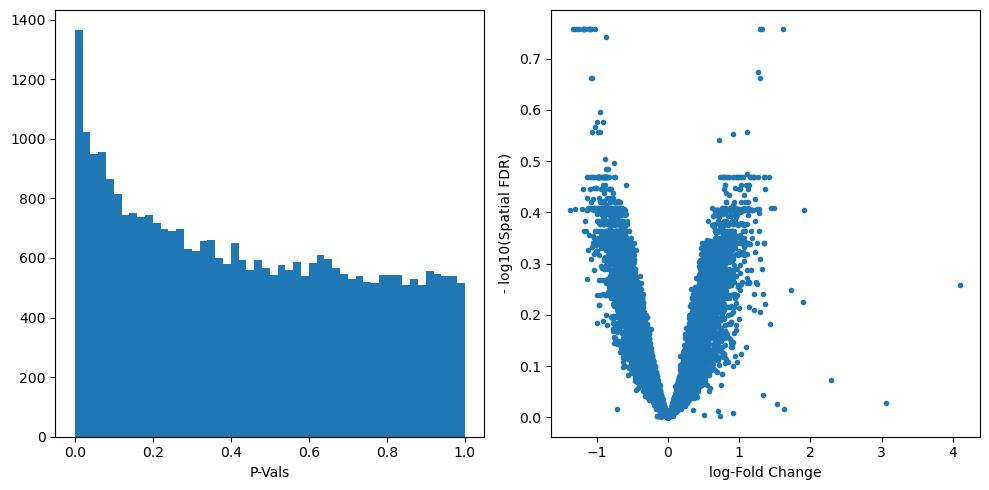

In [ ]:
# Plot p-value distribution and logFC versus spatial FDR for model diagnostics
old_figsize = plt.rcParams["figure.figsize"]
plt.rcParams["figure.figsize"] = [10, 5]
plt.subplot(1, 2, 1)
plt.hist(mdata_cd4_sex["milo"].var.PValue, bins=50)
plt.xlabel("P-Vals")
plt.subplot(1, 2, 2)
plt.plot(mdata_cd4_sex["milo"].var.logFC, -np.log10(mdata_cd4_sex["milo"].var.SpatialFDR), ".")
plt.xlabel("log-Fold Change")
plt.ylabel("- log10(Spatial FDR)")
plt.tight_layout()
plt.rcParams["figure.figsize"] = old_figsize

___

## Visualize embedding

In [ ]:
# Build neighbourhood graph for visualising Milo differential abundance results
milo.build_nhood_graph(mdata_cd4_sex)

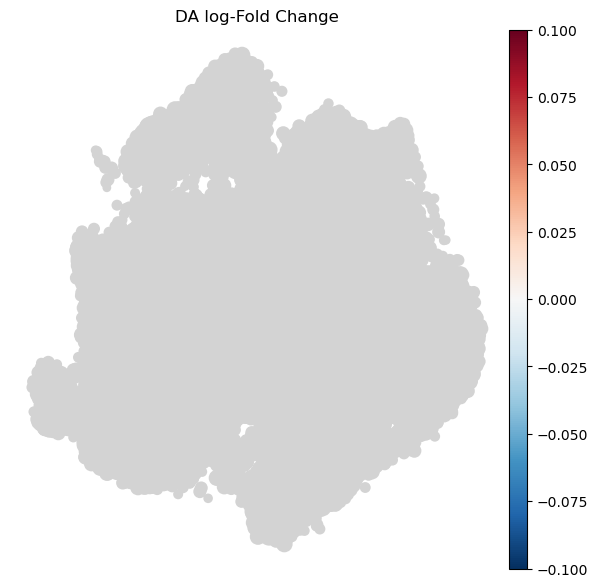

In [ ]:
# Plot neighbourhood-level sex-associated logFC values
plt.rcParams["figure.figsize"] = [7, 7]
milo.plot_nhood_graph(
    mdata_cd4_sex,
    alpha=0.1,  # SpatialFDR level (1%)
    min_size=1,  # Size of smallest dot
)

___

## Annotate Neighbourhoods by Cell Type

In [ ]:
# Assign dominant CD4 cell-type annotation to each Milo neighbourhood
milo.annotate_nhoods(mdata_cd4_sex, anno_col="pica_cell_type_complete_01_gdT_corrected")


Text(0.5, 0, 'celltype fraction')

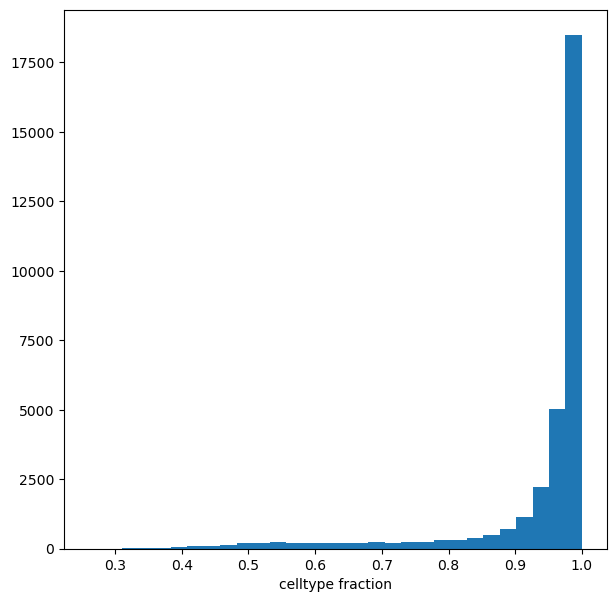

In [ ]:
# Assess annotation purity across neighbourhoods
plt.hist(mdata_cd4_sex["milo"].var["nhood_annotation_frac"], bins=30)
plt.xlabel("celltype fraction")

In [ ]:
# Label low-purity neighbourhoods as mixed to avoid over-interpreting ambiguous neighbourhoods
mdata_cd4_sex["milo"].var["nhood_annotation"] = mdata_cd4_sex["milo"].var["nhood_annotation"].cat.add_categories("Mixed")
mdata_cd4_sex["milo"].var.loc[mdata_cd4_sex["milo"].var["nhood_annotation_frac"] < 0.6, "nhood_annotation"] = "Mixed"

/home/s4575250/miniforge3/envs/milo/lib/python3.12/site-packages/pertpy/tools/_milo.py:1053: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.stripplot(


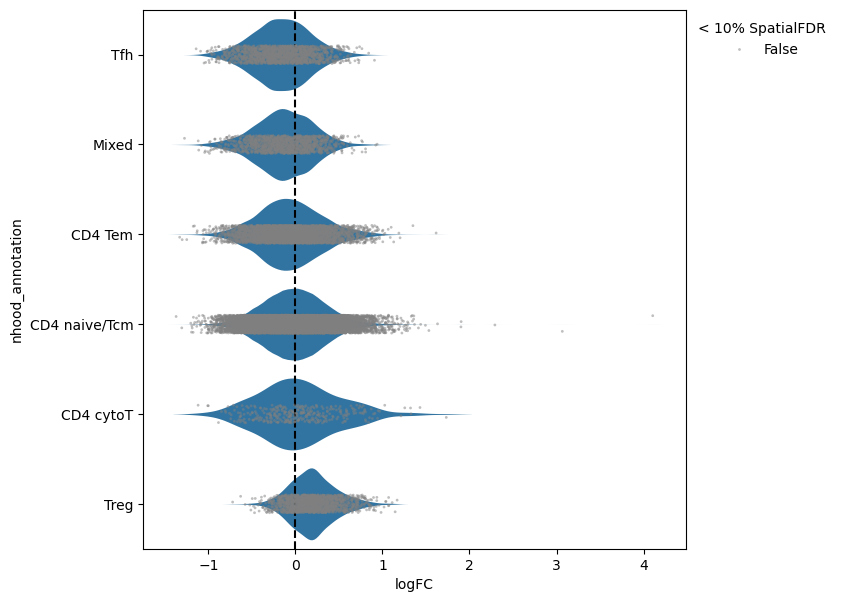

In [ ]:
# Generate beeswarm plot of neighbourhood-level sex effects grouped by annotation
milo.plot_da_beeswarm(mdata_cd4_sex, alpha=0.1)

In [ ]:
# Extract significant sex-associated neighbourhoods
sig_nhoods_cd4_sex = mdata_cd4_sex["milo"].var.query(
    "SpatialFDR < 0.1"
).copy()

sig_nhoods_cd4_sex.sort_values("logFC", ascending=False).head()

,index_cell,kth_distance,logCPM,logFC,PValue,FDR,SpatialFDR,Nhood_size,nhood_annotation,nhood_annotation_frac


In [22]:
sig_nhoods_cd4_sex.to_csv("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/03_milo/cd4_sig_nhood_sex_milo_results.csv")

___

## Diagnostic Visualisation of Sex Effects

<Axes: >

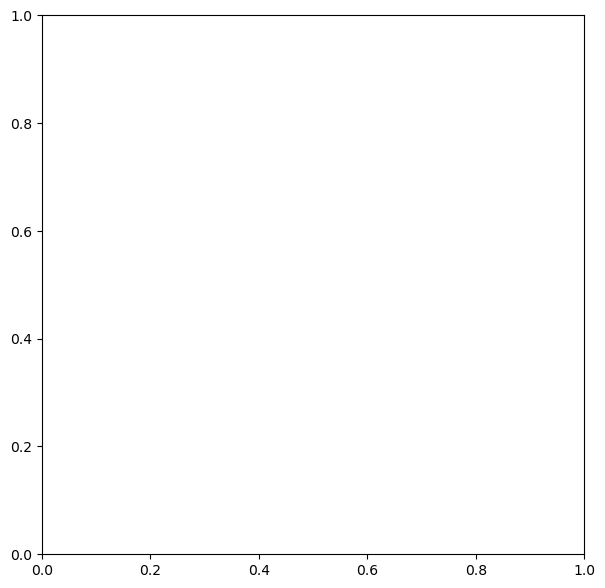

In [ ]:
# Visualise relationship between Sex-associated logFC and neighbourhood distance
sns.scatterplot(
    data=sig_nhoods_cd4_sex,
    x="logFC",
    y="kth_distance",
    hue=(sig_nhoods_cd4_sex["SpatialFDR"] < 0.05)
)

No significant neighbourhoods were identified in the sex-effect analysis (SpatialFDR < 0.1). Consequently, summaries of enriched and depleted neighbourhoods were not generated.

The remaining visualisations are presented for exploratory assessment of neighbourhood-level effect estimates.

___

## Visualization

### Significant Sex-Associated Neighbourhoods

In [ ]:
# Extract significant sex-associated neighbourhoods
pl_nhood_cd4_sex = (
    mdata_cd4_sex["milo"].var.query("SpatialFDR < 0.1")
    .sort_values("logFC", ascending=False)
    .index[:6]
)

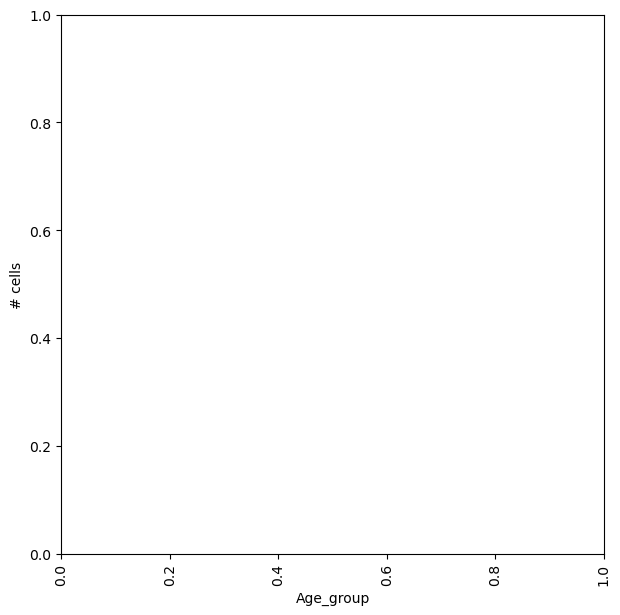

In [ ]:
# Visualise counts by age group for top sex-enriched neighbourhoods
milo.plot_nhood_counts_by_cond(mdata_cd4_sex, test_var="Age_group", subset_nhoods=pl_nhood_cd4_sex, log_counts=False)

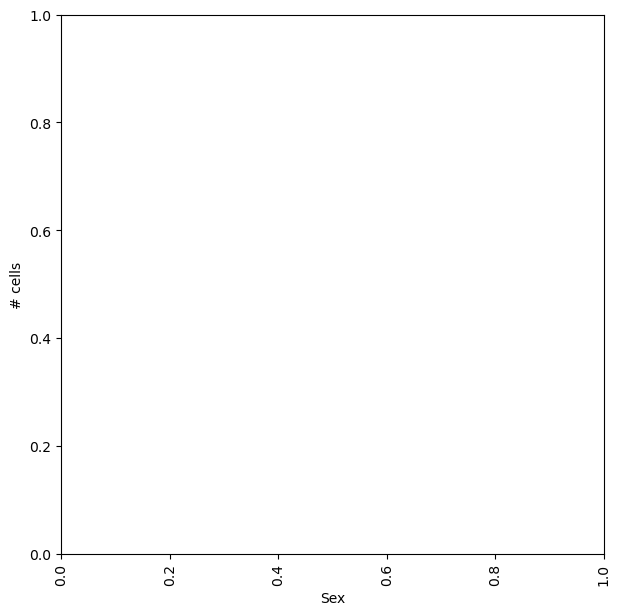

In [ ]:
# Visualise counts by sex for top sex-enriched neighbourhoods as an exploratory check
milo.plot_nhood_counts_by_cond(mdata_cd4_sex, test_var="Sex", subset_nhoods=pl_nhood_cd4_sex, log_counts=False)

### logFC Distribution by Neighbourhood Annotation

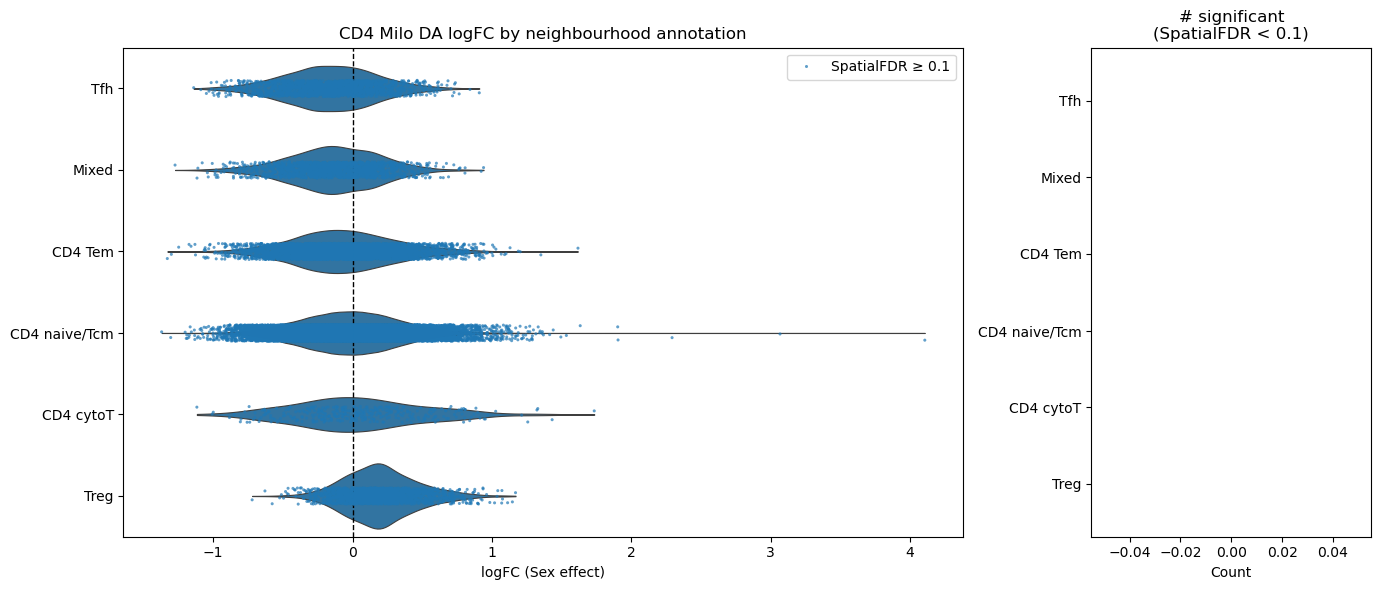

In [27]:
# full nhood results
df_cd4_sex = mdata_cd4_sex["milo"].var.copy()

# make sure the key columns exist
# df should already have: logFC, SpatialFDR, nhood_annotation
df_cd4_sex["sig"] = df_cd4_sex["SpatialFDR"] < 0.1

# (optional) order annotations by median logFC (most depleted on top)
order = (
    df_cd4_sex.groupby("nhood_annotation")["logFC"]
      .median()
      .sort_values()  # depleted (more negative) first
      .index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={"width_ratios":[3, 1]})

# ---- Panel A: logFC distribution by annotation ----
sns.violinplot(
    data=df_cd4_sex, y="nhood_annotation", x="logFC",
    order=order, inner=None, cut=0, linewidth=0.8, ax=axes[0]
)
sns.stripplot(
    data=df_cd4_sex, y="nhood_annotation", x="logFC",
    order=order, hue="sig", dodge=False, size=2.2,
    alpha=0.7, ax=axes[0]
)
axes[0].axvline(0, ls="--", c="k", lw=1)
axes[0].set_title("CD4 Milo DA logFC by neighbourhood annotation")
axes[0].set_xlabel("logFC (Sex effect)")
axes[0].set_ylabel("")

# clean up legend (keep only one)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles[:2], ["SpatialFDR ≥ 0.1", "SpatialFDR < 0.1"], title="", loc="upper right")

# ---- Panel B: counts of significant nhoods per annotation ----
sig_counts = (
    df_cd4_sex[df_cd4_sex["sig"]]
    .groupby("nhood_annotation")
    .size()
    .reindex(order, fill_value=0)  # order is already defined from left plot
)

# Use barh with same order to match left panel
axes[1].barh(sig_counts.index, sig_counts.values)
axes[1].set_title("# significant\n(SpatialFDR < 0.1)")
axes[1].set_xlabel("Count")
axes[1].set_ylabel("")

# Make sure y axis is in same order as left plot
axes[1].set_yticks(range(len(order)))
axes[1].set_yticklabels(order)
axes[1].invert_yaxis() 

plt.tight_layout()
plt.show()